# **PRÁCTICA 2**

##### **Iván Ciller López, 100522245**
##### **Mohamed Rida Chahdaoui Moujib, 100522202**

## **Cómo ejecutar este notebook**

Sigue estos pasos antes de ejecutar las celdas:

1. Crear y activar un entorno virtual (recomendado).
2. Instalar dependencias desde `requirements.txt`.
3. Seleccionar el kernel del entorno en Jupyter/VS Code.
4. Ejecutar el notebook de arriba a abajo.

## **APARTADO 1: CODIFICACIÓN DE VARIABLES**

Para comenzar con la práctica, empezamos viendo los distintos valores posibles para **Color** y **Spectral_Class**:

In [52]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

import dbcv

# Fijamos la semilla
np.random.seed(100522245)  # Semilla con NIA

# Cargamos los datos
df = pd.read_csv('stars_data.csv')

# Ver valores únicos y cuántos hay de cada uno en la Clase Espectral
print("--- Recuento de Clase Espectral ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Recuento de Colores ---")
# Ver valores únicos de Color
print(df['Color'].value_counts())

--- Recuento de Clase Espectral ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Recuento de Colores ---
Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64


Observamos que en **Spectral_Class** los valores son los esperados y, a priori, no hay nada que modificar (salvo convertirlos en número). No obstante, en **Color** podemos ver que hay colores que son los mismos pero están escritos de manera diferente, por lo que el algoritmo los tomará como colores distintos, como por ejemplo *Blue-white*, *Blue White*, *Blue white* y *Blue-White*, que son el mismo color pero difieren en mayúsculas, minúsculas y guiones. Por ello, a continuación abordaremos este problema poniendo todos los colores en un formato común:


In [53]:
# Normalización inicial de Color: quitamos espacios raros, pasamos a minúsculas y quitamos guiones
df['Color'] = df['Color'].str.lower().str.replace('-', ' ').str.strip()

# Hacemos un diccionario de corrección (mapeo de nombres feos a nombres limpios)
# Incluimos todas las variantes obtenidas en value_counts y les asignamos una común
limpieza_colores = {
    'red': 'red',
    'blue': 'blue',
    'blue white': 'blue white',
    'blue-white': 'blue white',
    'yellow-white': 'yellow white',
    'white yellow': 'yellow white',
    'yellowish white': 'yellow white',
    'white': 'white',
    'whitish': 'white',
    'yellowish': 'yellow',
    'orange': 'orange',
    'orange red': 'orange red',
    'pale yellow orange': 'pale yellow orange'
}

# Aplicamos la limpieza usando .replace() para no borrar los que ya están bien
df['Color'] = df['Color'].replace(limpieza_colores)

# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Limpia) ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Colores (Limpios y agrupados) ---")
print(df['Color'].value_counts())

# Verificamos si hay algún valor nulo después de la limpieza
if df[['Color', 'Spectral_Class']].isnull().values.any():
    print("\nHay valores nulos")
else:
    print("\nNo hay valores nulos")

--- Clase Espectral (Limpia) ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Colores (Limpios y agrupados) ---
Color
red                   112
blue                   56
blue white             41
white                  12
yellow white           12
yellow                  3
orange                  2
pale yellow orange      1
orange red              1
Name: count, dtype: int64

No hay valores nulos


Como podemos observar, hemos conseguido poner todos los colores en un formato común, que consiste en que todos los colores estén en minúscula y sin guiones. Esto lo logramos usando **lower** para las minúsculas, **replace** para sustituir los guiones por espacios y **strip** por si hubiese algún espacio raro en los nombres. A continuación, creamos un diccionario para renombrar a los colores y usamos **replace** para sustituir los colores por su nuevo nombre. Finalmente, comprobamos que todo está correctamente hecho y comprobamos si han aparecido nulos (no han aparecido). Ahora debemos llevar a cabo la **codificación ordinal** (importante hacerla antes de **PCA**, pues este solo entiende de números):

In [54]:
# Definimos orden lógico para color de menor a mayor temperatura/energía
# Para ello, nos fijamos en la tabla del enunciado y las relaciones color-temperatura
orden_color = {
    'red': 0,
    'orange red': 1, 
    'orange': 2, 
    'pale yellow orange': 3, 
    'yellow': 4, 
    'white': 5,            
    'yellow white': 6,     
    'blue white': 7, 
    'blue': 8
}

# Definimos orden lógico para spectral_class de menor a mayor temperatura/energía
# Para ello, nos fijamos en la secuencia del enunciado y la mención de que O es la más caliente y M la más fría
orden_espectral = {
    'M': 0, 
    'K': 1, 
    'G': 2, 
    'F': 3, 
    'A': 4, 
    'B': 5, 
    'O': 6
}

# Aplicamos el mapeo para crear las columnas numéricas
df['Rango_Color'] = df['Color'].map(orden_color)
df['Rango_Espectral'] = df['Spectral_Class'].map(orden_espectral)


# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Numerada) ---")
print(df['Rango_Espectral'].value_counts())

print("\n--- Colores (Numerados) ---")
print(df['Rango_Color'].value_counts())

# Verificación final de nulos
print("Nulos en Rango_Color:", df['Rango_Color'].isnull().sum())
print("Nulos en Rango_Espectral:", df['Rango_Espectral'].isnull().sum())

--- Clase Espectral (Numerada) ---
Rango_Espectral
0    111
5     46
6     40
4     19
3     17
1      6
2      1
Name: count, dtype: int64

--- Colores (Numerados) ---
Rango_Color
0    112
8     56
7     41
5     12
6     12
4      3
2      2
3      1
1      1
Name: count, dtype: int64
Nulos en Rango_Color: 0
Nulos en Rango_Espectral: 0


Para la **codificación ordinal** comenzamos escribiendo dos diccionarios, uno para **Color** y otro para **Spectral_Class**. Ambas columnas son ordinales, pues sus atributos se pueden ordenar en función de la temperatura (más frías a más calientes). En **Color**, tomamos como referencia que *red* es el extremo frío y *blue* el extremo caliente. Con esa lógica construimos una jerarquía intermedia coherente (*orange*, *yellow*, *white*, *blue white*, etc.). Además, tenemosm muy en cuenta la tabla dada en el enunciado que muestra, por ejemplo, que **temperatura de yellow < temperatura white < temperetaura yellow white**. De esta manera, además, respetamos las diferencias físicas, astronómicas y de temperatura entre los colores. No obstante, esta codificación provocará la existencia de ruido (por ejemplo, para **pale yellow orange** solo hay una estrella, lo que será ruido), pero preferimos evitar la pérdida de información que evitar el ruido.

Para la codificación de **Spectral_Class** seguimos la secuencia indicada en el enunciado, donde **O** representa las estrellas más calientes y **M** las más frías. Finalmente, comprobamos que todo está como esperábamos y verificamos que no existen nulos.

A continuación veremos si el resto de atributos necesitan preprocesado:

In [55]:
# Lista de atributos numéricos originales
atributos_restantes = ['Temperature', 'L', 'R', 'A_M']

print("=== ANÁLISIS DE ATRIBUTOS RESTANTES ===")

for col in atributos_restantes:
    print(f"\n--- Columna: {col} ---")
    
    # Comprobamos nulos en esta columna
    nulos = df[col].isnull().sum()
    print(f"Valores nulos: {nulos}")
    
    # Obtenemos los distintos valores
    print(df[col].value_counts())
    
    # Vemos el rango (Mínimo y Máximo)
    # Útil para detectar si hay algún "0" que no tenga sentido
    print(f"Rango: [{df[col].min()} , {df[col].max()}]")

print("\n" + "="*30)

# Verificación global de nulos
if df.isnull().values.any():
    print("Hay nulos")
else:
    print("No hay nulos")

=== ANÁLISIS DE ATRIBUTOS RESTANTES ===

--- Columna: Temperature ---
Valores nulos: 0
Temperature
3600     3
2600     2
2650     2
3625     2
3450     2
        ..
38940    1
30839    1
8829     1
9235     1
37882    1
Name: count, Length: 228, dtype: int64
Rango: [1939 , 40000]

--- Columna: L ---
Valores nulos: 0
L
200000.00000    5
0.00067         3
0.00014         3
0.00098         3
0.00240         2
               ..
374830.00000    1
834042.00000    1
537493.00000    1
404940.00000    1
294903.00000    1
Name: count, Length: 208, dtype: int64
Rango: [8e-05 , 849420.0]

--- Columna: R ---
Valores nulos: 0
R
0.11       3
0.24       3
1324.00    3
36.00      3
0.16       2
          ..
1130.00    1
1194.00    1
1423.00    1
1112.00    1
1783.00    1
Name: count, Length: 216, dtype: int64
Rango: [0.0084 , 1948.5]

--- Columna: A_M ---
Valores nulos: 0
A_M
 12.23    3
 17.45    2
 14.23    2
-7.22     2
-9.20     2
         ..
-9.93     1
-10.63    1
-10.73    1
-11.23    1
-7.80   

Como podemos observar, el resto de atributos que faltaban por comprobar presentan valores de acuerdo a lo esperado y a lo que se refleja en la tabla de ejemplo dada en el enunciado. También comprobamos si hay nulos y no es el caso. 

Una vez resuelto todo esto, abordamos el desarrollo de **PCA**:




## **APARTADO 2: IMPLEMENTACIÓN DE PCA**

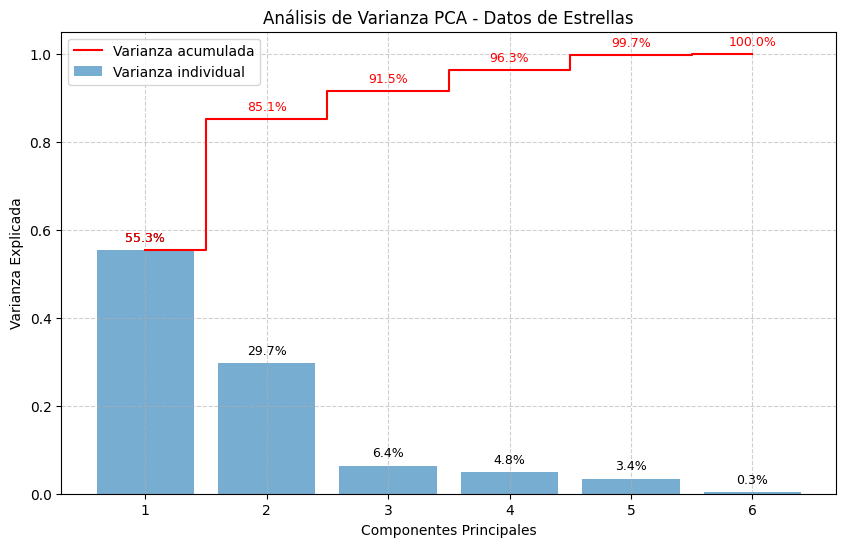

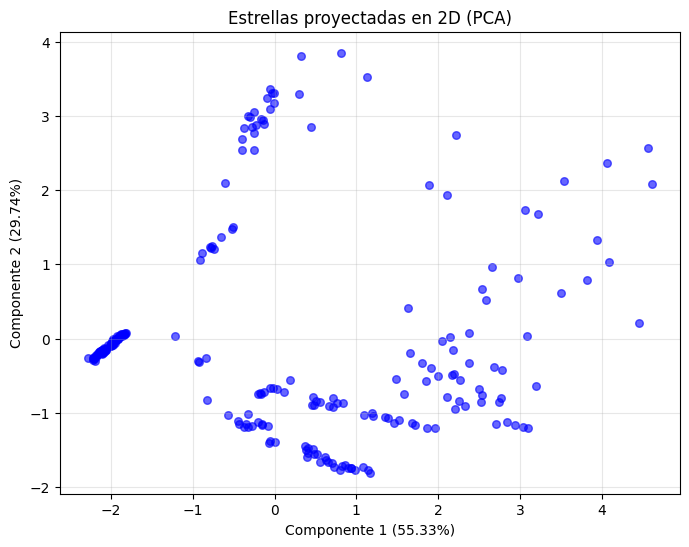

In [56]:
# Preparamos los datos (X)
# Usamos las variables originales + las que hemos mapeado a números
features = ['Temperature', 'L', 'R', 'A_M', 'Rango_Color', 'Rango_Espectral']
X = df[features]

# Creamos el Pipeline 
# Paso 1: Escalar, Paso 2: PCA (sin número de componentes para ver todas primero)
pipeline_exploratorio = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

# Ajustamos y transformamos
X_pca_full = pipeline_exploratorio.fit_transform(X)
pca_step = pipeline_exploratorio.named_steps['pca']

# Visualizamos la varianza
varianza_explicada = pca_step.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

# Añadimos etiquetas de porcentaje y hacemos que se interprete mejor visualmente
for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    plt.text(i + 1, ev + 0.02, f"{ev:.1%}", ha='center', fontsize=9)
    plt.text(i + 1, cv + 0.02, f"{cv:.1%}", ha='center', color='red', fontsize=9)

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Análisis de Varianza PCA - Datos de Estrellas')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Ahora aplicamos la reducción a 2 componentes
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=100522245)) # Semilla de NIA
])

X_reduced = pipeline_final.fit_transform(X)

# Guardamos el resultado en un DataFrame para el clustering posterior
df_pca_estrellas = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])

# Visualización final en 2D
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_estrellas['PC1'], df_pca_estrellas['PC2'], alpha=0.6, c='blue', s=30)
plt.title('Estrellas proyectadas en 2D (PCA)')
plt.xlabel(f'Componente 1 ({varianza_explicada[0]:.2%})')
plt.ylabel(f'Componente 2 ({varianza_explicada[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.show()

Para desarrollar **PCA**, primero creamos la matriz de datos **X**, que únicamente contiene las variables que vamos a usar en el modelo (ya que **Color** y **Spectral_Class** no las usamos al no ser numéricas). A continuación, construimos un **Pipeline** que primero escala con **StandardScaler** y después aplica **PCA** sin especificar el número de componentes, con el objetivo de observar la importancia de cada componente para explicar los datos (aunque se nos indica que debemos reducir a 2 dimensiones, creemos que es buena práctica analizarlo primero). Después, entrenamos el pipeline, transformamos los datos y accedemos al objeto **PCA**. A partir de ese objeto, calculamos la **varianza explicada** (para ver cuánta información captura cada componente) y la **varianza acumulada** (para ver cuánta información se acumula en total). Una vez hecho esto, representamos un gráfico para reconocer el ***elbow***, que nos ayuda a decidir en qué momento podemos dejar de añadir componentes porque las mejoras ya no son significativas. Como se puede observar en dicho gráfico, la **primera componente captura el 55,3%** y la **segunda componente el 29,7%**, elevando la **captura total al 85,1%**. La **tercera componente solo captura el 6,4%**, por lo que no creemos necesario incluirla; por eso, nuestro **PCA será de 2 dimensiones**, como indica el enunciado. Ahora ya podemos aplicar la **reducción a 2 componentes** en **PCA** (haciendo antes **StandardScaler**, obviamente). Finalmente, guardamos el resultado (**PC1 y PC2**) en un nuevo **DataFrame** con el objetivo de usarlo posteriormente en clustering y, además, observamos esa transformación en 2 dimensiones para comprobar si se forman grupos (y, efectivamente, observamos que sí: hay un grupo más a la izquierda, otro más abajo, otro arriba...).

A continuación, procederemos a aplicar los diferentes **algoritmos de clustering**:

## **APARTADO 3: ALGORITMOS DE CLUSTERING**

#### **APARTADO 3.1: AJUSTE HIPERPARÁMETROS K-MEANS**

Comenzamos este apartado aplicando **K-Means**. En primer lugar, debemos decidir el número **K** de clústeres que queremos obtener. Para ello, implementamos el **Método del Codo** y el **Método Silhouette** con el objetivo de tomar una decisión robusta, ya que compararemos el número sugerido por ambos métodos:

In [57]:
# Usamos los datos del PCA
X_input = X_reduced

# Establecemos el rango de K a evaluar
range_n_clusters = range(2, 11)
inertias = []
silhouette_vals = []

# Entrenamos un modelo K-Means para cada número de clústeres
for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=100522245
    )

    # Aprende centroides y asigna etiquetas
    labels_kmeans = modelo_kmeans.fit_predict(X_input)

    # Guardamos métricas
    inertias.append(modelo_kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_input, labels_kmeans))

# Mejor K según Silhouette
best_k_sil_kmeans = range_n_clusters[np.argmax(silhouette_vals)]
print(f"Mejor K según Silhouette (K-Means): {best_k_sil_kmeans}")

Mejor K según Silhouette (K-Means): 6


Para seleccionar el mejor número de clústeres en **K-Means**, evaluamos dos criterios complementarios para cada valor de $K$ entre 2 y 10. El **Método del Codo** usa la inercia (suma de distancias internas al centroide): cuanto menor, mejor compactación, aunque llega un punto donde la mejora deja de ser significativa. El **Método Silhouette** mide cohesión y separación simultáneamente: valores más altos indican clústeres mejor definidos. En la siguiente celda visualizamos ambas curvas para tomar la decisión final de $K$.

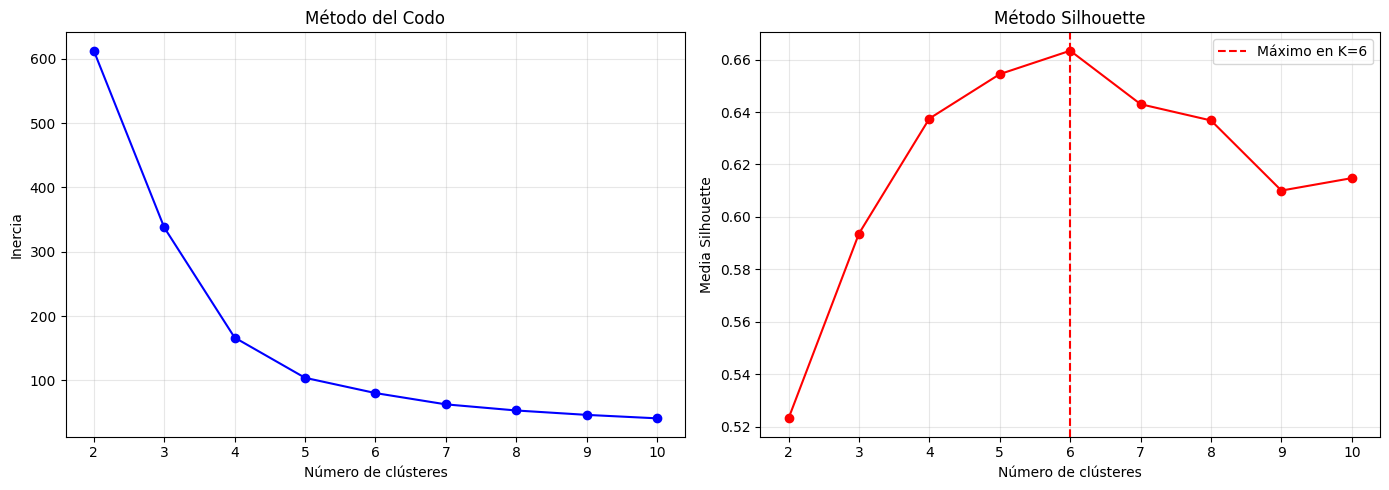

In [58]:
# Visualización de criterios para elegir K
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(range_n_clusters, inertias, marker='o', color='blue')
ax1.set_title("Método del Codo")
ax1.set_xlabel('Número de clústeres')
ax1.set_ylabel('Inercia')
ax1.grid(alpha=0.3)

# Gráfico de Silhouette
ax2.plot(range_n_clusters, silhouette_vals, marker='o', color='red')
ax2.axvline(best_k_sil_kmeans, color='r', linestyle='--', label=f"Máximo en K={best_k_sil_kmeans}")
ax2.set_title("Método Silhouette")
ax2.set_xlabel('Número de clústeres')
ax2.set_ylabel('Media Silhouette')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A partir de las gráficas, el **Método del Codo** muestra una zona de inflexión razonable en torno a $K=4$, $K=5$ y $K=6$, por lo que no ofrece una única elección clara. Sin embargo, el **Método Silhouette** alcanza su valor máximo en $K=6$, indicando la mejor combinación de cohesión interna y separación entre grupos. Por ello, seleccionamos **$K=6$** como hiperparámetro óptimo de K-Means. A continuación mostramos como quedaría visualmente la agrupación de los clusters:

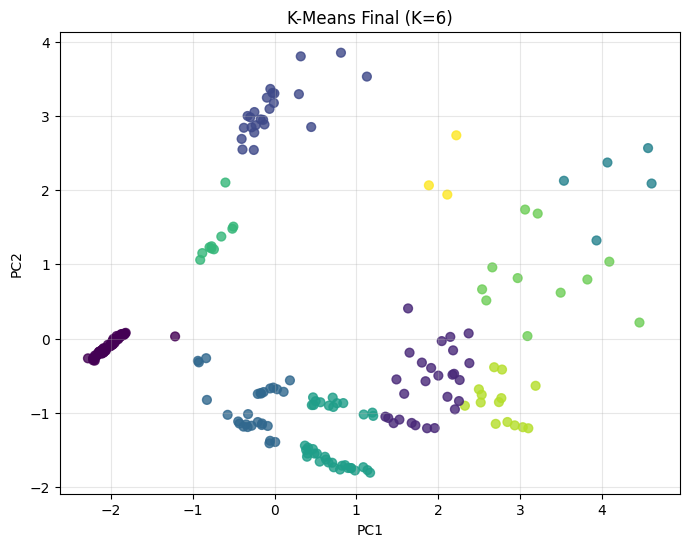

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_pca_estrellas['PC1'],
    df_pca_estrellas['PC2'],
    c=labels_kmeans,
    cmap='viridis',
    s=40,
    alpha=0.8
)
plt.title(f"K-Means Final (K={best_k_sil_kmeans})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

Ahora pasamos a **Hierarchical Clustering** para elegir el mejor tipo de *linkage* y el número de clusters.

#### **APARTADO 3.2: AJUSTE HIPERPARÁMETROS HIERARCHICAL CLUSTERING**

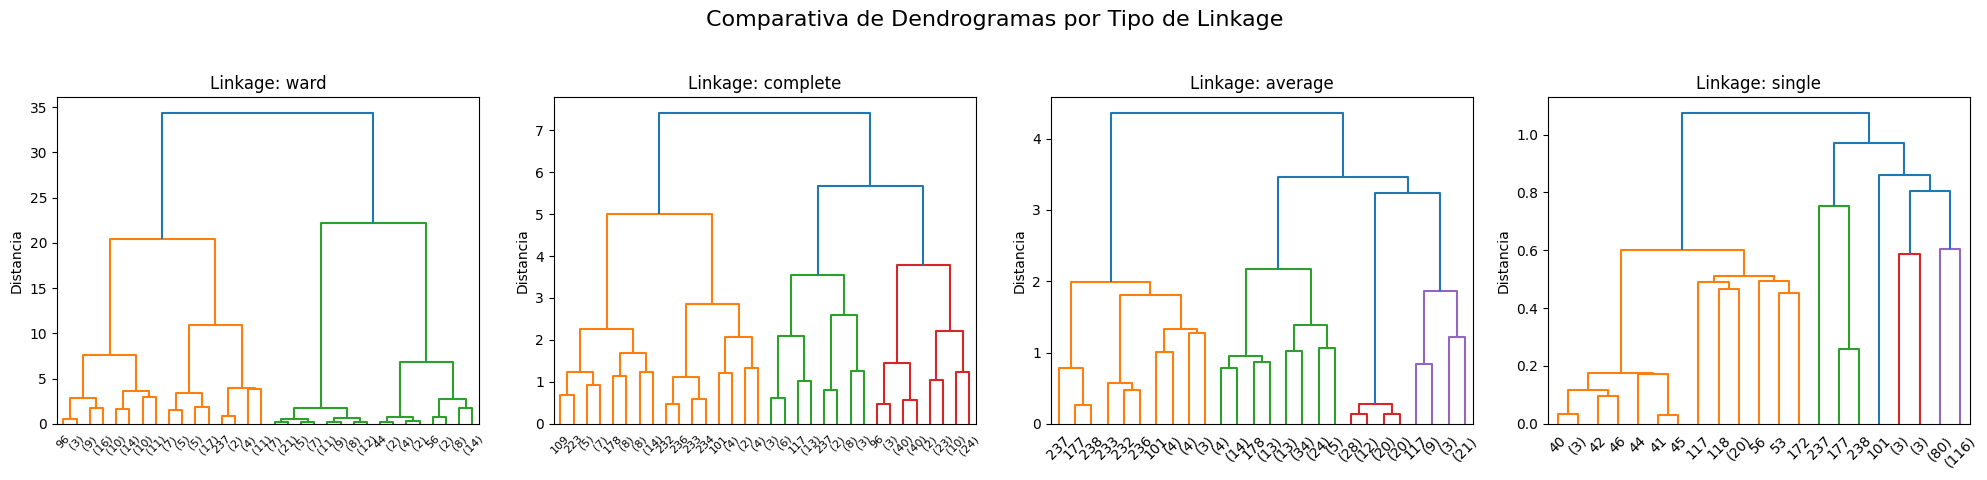

In [60]:
# Usamos los datos del PCA
X_input = X_reduced

# Comparativa visual de linkages
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, link in enumerate(['ward', 'complete', 'average', 'single']):
    Z_temp = sch.linkage(X_input, method=link)
    sch.dendrogram(Z_temp, ax=axs[i], truncate_mode='level', p=4)
    axs[i].set_title(f"Linkage: {link}")
    axs[i].set_ylabel("Distancia")

plt.suptitle("Comparativa de Dendrogramas por Tipo de Linkage", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

=== COMPARATIVA CUANTITATIVA: SILHOUETTE POR LINKAGE Y K ===
Tabla de Silhouette para cada combinación:


Linkage,average,complete,single,ward
K,,,,
2,0.3852,0.4294,0.3731,0.5083
3,0.4981,0.5066,0.2868,0.5779
4,0.6075,0.4634,0.2541,0.6302
5,0.6238,0.6431,0.2992,0.6275
6,0.6066,0.6128,0.2833,0.6154
7,0.6290,0.5997,0.5142,0.6313
8,0.6291,0.6019,0.5291,0.6276
9,0.6289,0.5688,0.4157,0.6300
10,0.6313,0.5491,0.4196,0.6307



MEJOR CONFIGURACIÓN JERÁRQUICA: linkage=COMPLETE, K=5, Silhouette=0.6431


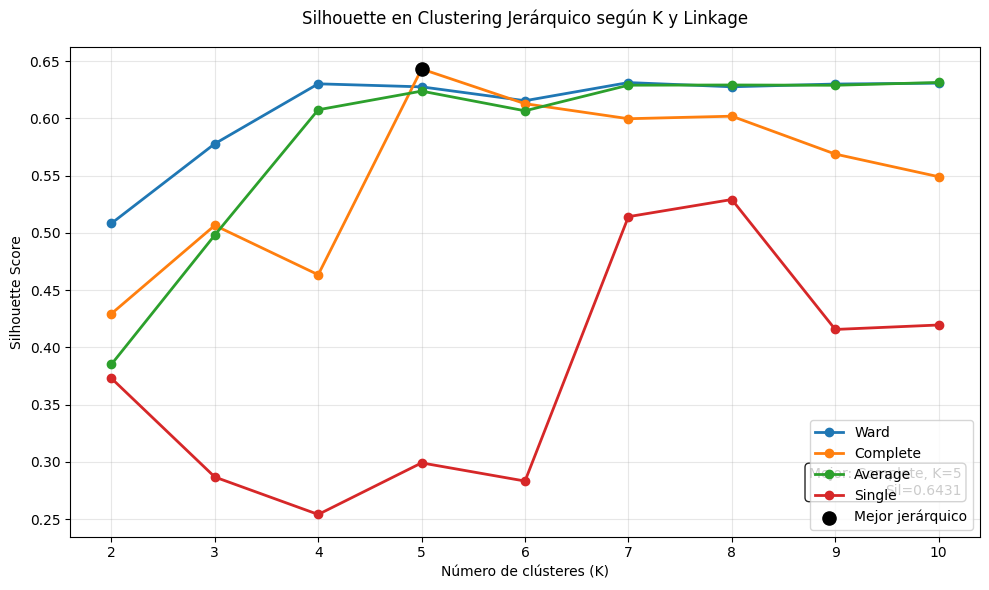

In [61]:
# Comparativa cuantitativa: Silhouette para cada linkage y número de clústeres
linkages = ['ward', 'complete', 'average', 'single']
range_n_clusters = range(2, 11)
resultados_hier = []

print("=== COMPARATIVA CUANTITATIVA: SILHOUETTE POR LINKAGE Y K ===")

for link in linkages:
    for n_clusters in range_n_clusters:
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=link)
        labels = model.fit_predict(X_input)
        if len(set(labels)) > 1:
            sil = silhouette_score(X_input, labels)
        else:
            sil = -1
        resultados_hier.append({
            'Linkage': link,
            'K': n_clusters,
            'Silhouette': sil
        })

resultados_hier_df = pd.DataFrame(resultados_hier)
tabla_silhouette_hier = resultados_hier_df.pivot(index='K', columns='Linkage', values='Silhouette')

print("Tabla de Silhouette para cada combinación:")
display(tabla_silhouette_hier.round(4))

best_hier_row = resultados_hier_df.loc[resultados_hier_df['Silhouette'].idxmax()]
best_linkage = best_hier_row['Linkage']
k_hier_final = int(best_hier_row['K'])
best_k_sil_hier = k_hier_final
best_sil_hier = float(best_hier_row['Silhouette'])

print(f"\nMEJOR CONFIGURACIÓN JERÁRQUICA: linkage={best_linkage.upper()}, K={k_hier_final}, Silhouette={best_sil_hier:.4f}")

# Gráfico de líneas: evolución del Silhouette según K para cada linkage
plt.figure(figsize=(10, 6))

for link in linkages:
    subset = resultados_hier_df[resultados_hier_df['Linkage'] == link]
    plt.plot(subset['K'], subset['Silhouette'], marker='o', linewidth=2, label=link.capitalize())

plt.scatter(k_hier_final, best_sil_hier, color='black', s=90, zorder=5, label='Mejor jerárquico')
ax = plt.gca()
ax.text(
    0.98, 0.08,
    f"Mejor: {best_linkage.capitalize()}, K={k_hier_final}\nSil={best_sil_hier:.4f}",
    transform=ax.transAxes,
    ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.85),
    fontsize=10
)

plt.title("Silhouette en Clustering Jerárquico según K y Linkage", pad=16)
plt.xlabel("Número de clústeres (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(range_n_clusters))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Tras comparar los dendrogramas visualmente, realizamos una **evaluación cuantitativa completa** del clustering jerárquico. Para ello, evaluamos cada combinación de **tipo de linkage** y **número de clústeres** y seleccionamos la mejor configuración jerárquica según *Silhouette Score*.

La idea es que cada algoritmo se optimice con sus propios hiperparámetros: K-Means con su mejor $K$, clustering jerárquico con su mejor pareja `linkage + K`, y DBSCAN con sus mejores valores de `eps` y `min_samples` usando DBCV.


--- ANÁLISIS COMPLEMENTARIO DEL DENDROGRAMA (COMPLETE) ---
Mayor salto detectado en el índice de fusión: 237
Número de clústeres sugerido por salto de altura: 2
Configuración seleccionada por Silhouette: linkage=complete, K=5, Silhouette=0.6431


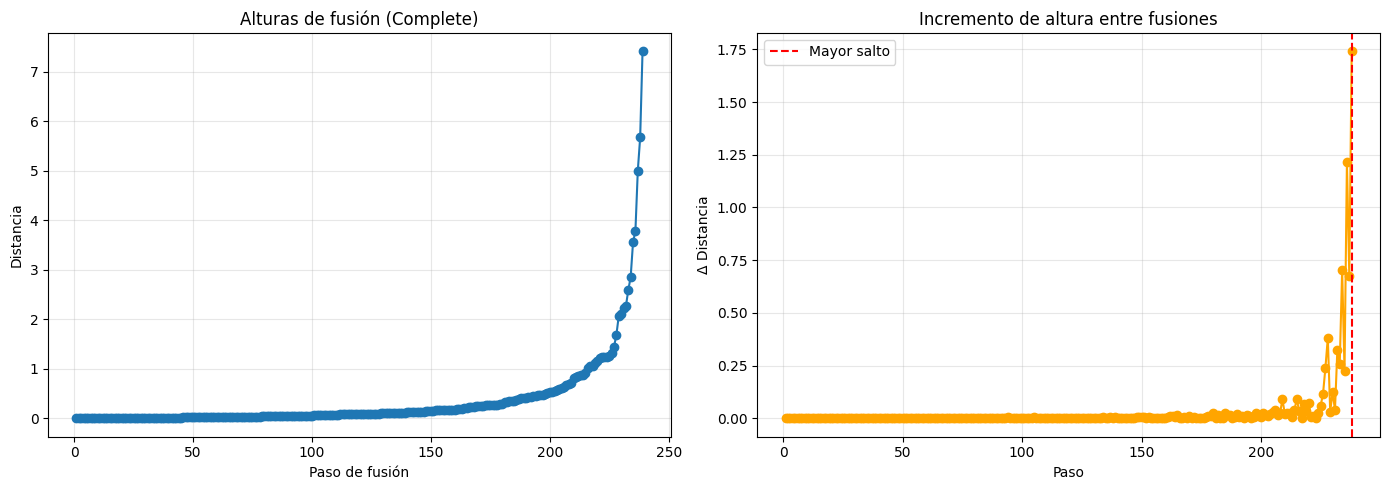

In [62]:
# Análisis complementario del dendrograma para el linkage ganador
Z = sch.linkage(X_input, method=best_linkage)
heights = Z[:, 2]
diffs = np.diff(heights)
idx_max_jump = np.argmax(diffs)

# Estimación del número de clústeres si se corta antes del mayor salto de altura
n_clusters_h_mat = len(heights) - idx_max_jump

print(f"--- ANÁLISIS COMPLEMENTARIO DEL DENDROGRAMA ({best_linkage.upper()}) ---")
print(f"Mayor salto detectado en el índice de fusión: {idx_max_jump}")
print(f"Número de clústeres sugerido por salto de altura: {n_clusters_h_mat}")
print(f"Configuración seleccionada por Silhouette: linkage={best_linkage}, K={k_hier_final}, Silhouette={best_sil_hier:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(heights) + 1), heights, marker='o')
ax[0].set_title(f"Alturas de fusión ({best_linkage.capitalize()})")
ax[0].set_xlabel("Paso de fusión")
ax[0].set_ylabel("Distancia")
ax[0].grid(alpha=0.3)

ax[1].plot(range(1, len(diffs) + 1), diffs, marker='o', color='orange')
ax[1].axvline(x=idx_max_jump + 1, color='r', linestyle='--', label='Mayor salto')
ax[1].set_title("Incremento de altura entre fusiones")
ax[1].set_xlabel("Paso")
ax[1].set_ylabel("Δ Distancia")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### **Análisis Detallado**

Para el modelo jerárquico se evalúan todas las combinaciones entre `ward`, `complete`, `single` y `average` para $K \in [2, 10]$, y se selecciona la combinación con mayor *Silhouette Score*.

En esta ejecución, la mejor configuración jerárquica es **complete con K=5**, con un *Silhouette Score* aproximado de **0.6431**. Por tanto, esta es la versión del algoritmo jerárquico que debe compararse contra el mejor K-Means, no una versión fijada manualmente a un número concreto de clústeres.

El análisis del salto de altura del dendrograma se mantiene como información complementaria, pero no se usa como criterio único de decisión porque tiende a ser más conservador. Para la comparación final, el modelo jerárquico que compite contra K-Means y DBSCAN es el mejor modelo jerárquico encontrado: **linkage complete y K=5**.

También puede comentarse $K=6$ como referencia astronómica, ya que el enunciado muestra seis clases teóricas, pero no debe imponerse como restricción durante el ajuste de hiperparámetros.

A continuación mostramos como se verían visualmente los clusters con el linkage más óptimo:

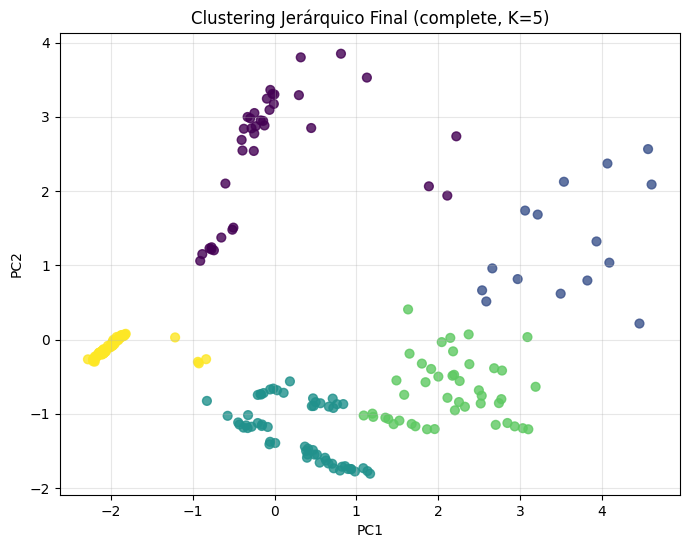

In [63]:
# VISUALIZACIÓN FINAL DE CLUSTERS

modelo_hc_final = AgglomerativeClustering(
    n_clusters=k_hier_final,
    linkage=best_linkage
)

labels_hierarchichal = modelo_hc_final.fit_predict(X_input)

plt.figure(figsize=(8,6))
plt.scatter(
    df_pca_estrellas['PC1'],
    df_pca_estrellas['PC2'],
    c=labels_hierarchichal,
    cmap='viridis',
    s=40,
    alpha=0.8
)

plt.title(f"Clustering Jerárquico Final ({best_linkage}, K={k_hier_final})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

#### **APARTADO 3.3: AJUSTE HIPERPARÁMETROS DBSCAN**

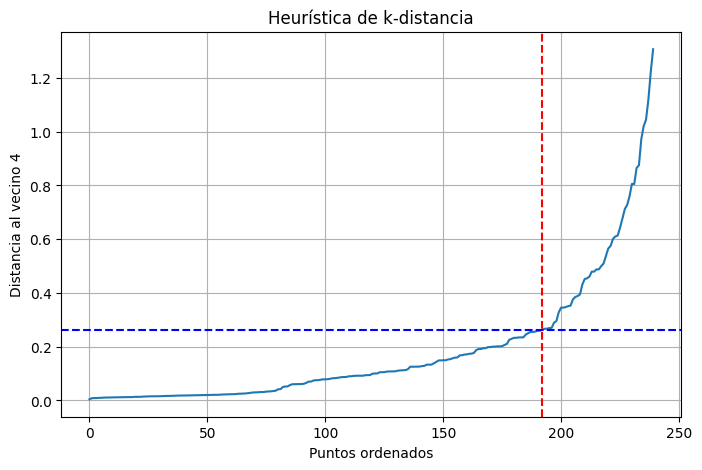

eps sugerido ≈ 0.263


In [64]:
# Definimos un min_samples inicial (regla general: 2 * dimensiones = 4)
min_samples_heur = 4

# Calculamos las distancias al vecino k-ésimo
nn = NearestNeighbors(n_neighbors=min_samples_heur)
nn.fit(X_reduced)
distances, indices = nn.kneighbors(X_reduced)

# Graficamos
sorted_distances = np.sort(distances[:, min_samples_heur-1], axis=0)

# Elegimos un punto cerca del 80% (heurística común)
x_point = int(len(sorted_distances) * 0.8)
y_value = sorted_distances[x_point]

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.title("Heurística de k-distancia")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {min_samples_heur}")

# Marcar codo aproximado
plt.axvline(x=x_point, color='r', linestyle='--')
plt.axhline(y=y_value, color='b', linestyle='--')

plt.grid(True)
plt.show()

print(f"eps sugerido ≈ {y_value:.3f}")

Se observa que **el codo se encuentra en un rango entre 0.20 y 0.40, recomendándose eps=0.263**. Este rango se tomará como punto de partida para el ajuste fino de hiperparámetros mediante la métrica DBCV:

In [65]:
# Definimos rangos basados en lo que vimos en la gráfica anterior
# Observamos que el codo está entre 0.20 y 0.40, por lo que probamos valores en ese rango
eps_values = [0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.263, 0.27, 0.28, 0.29, 0.30, 0.31, 0.32, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40]
min_samples_values = [3, 4, 5, 6]

print(f"{'MS':<3} | {'EPS':<4} | {'Clusters':<8} | {'% Ruido':<8} | {'DBCV Score'}")
print("-" * 50)

best_dbcv = -1
best_params = {}
resultados_dbscan = []

for ms in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_reduced)
        labels_dbscan = db.labels_
        n_clusters = len(set(labels_dbscan) - {-1})
        
        if n_clusters > 1:
            # Importante: DBCV mide densidad, el valor más alto es el mejor
            try:
                score = dbcv.dbcv(X_reduced, labels_dbscan)
            except:
                score = -1
            n_noise = list(labels_dbscan).count(-1)
            perc_noise = (n_noise / len(labels_dbscan)) * 100
            
            print(f"{ms:<3} | {eps:<4.2f} | {n_clusters:<8} | {perc_noise:>7.1f}% | {score:.4f}")

            resultados_dbscan.append({
                'eps': eps,
                'min_samples': ms,
                'n_clusters': n_clusters,
                'perc_noise': perc_noise,
                'dbcv': score
            })
            
            if score > best_dbcv and perc_noise < 20:
                best_dbcv = score
                best_params = {'eps': eps, 'min_samples': ms, 'labels': labels_dbscan}

print(f"\nMEJOR CONFIGURACIÓN: {best_params['eps']} eps, {best_params['min_samples']} ms (DBCV: {best_dbcv:.4f})")
df_dbscan = pd.DataFrame(resultados_dbscan)
df_dbscan = df_dbscan.sort_values(by='dbcv', ascending=False)

print("\nTOP CONFIGURACIONES DBSCAN:")
display(df_dbscan.head(10))

MS  | EPS  | Clusters | % Ruido  | DBCV Score
--------------------------------------------------
3   | 0.20 | 14       |    15.8% | 0.7899
3   | 0.21 | 13       |    15.4% | 0.7829
3   | 0.22 | 13       |    15.4% | 0.7829
3   | 0.23 | 13       |    14.2% | 0.7736
3   | 0.24 | 13       |    13.8% | 0.7764
3   | 0.25 | 13       |    13.8% | 0.7764
3   | 0.26 | 13       |    13.8% | 0.7764
3   | 0.27 | 11       |    13.8% | 0.6890
3   | 0.28 | 11       |    13.8% | 0.6890
3   | 0.29 | 10       |    13.8% | 0.7295
3   | 0.30 | 8        |    13.3% | 0.6567
3   | 0.31 | 8        |    12.5% | 0.6600
3   | 0.32 | 8        |    11.7% | 0.6151
3   | 0.34 | 9        |    10.0% | 0.6264
3   | 0.35 | 9        |     9.6% | 0.6297
3   | 0.36 | 8        |     9.6% | 0.5403
3   | 0.37 | 7        |     8.3% | 0.7208
3   | 0.38 | 7        |     7.9% | 0.7241
3   | 0.39 | 7        |     7.9% | 0.7241
3   | 0.40 | 7        |     7.9% | 0.7241
4   | 0.20 | 11       |    21.7% | 0.7483
4   | 0.21 | 11      

,eps,min_samples,n_clusters,perc_noise,dbcv
58,0.39,5,4,12.500000,0.830935
59,0.40,5,4,12.500000,0.830935
78,0.39,6,4,12.500000,0.830935
79,0.40,6,4,12.500000,0.830935
39,0.40,4,4,12.500000,0.830935
38,0.39,4,4,12.500000,0.830935
37,0.38,4,4,12.500000,0.830935
36,0.37,4,4,12.500000,0.830935
56,0.37,5,4,12.916667,0.827343
57,0.38,5,4,12.916667,0.827343


**El ajuste de los hiperparámetros de DBSCAN la realizamos en dos fases**: una **estimación inicial basada en la heurística del gráfico k-distance** y una **optimización posterior mediante la métrica DBCV**. En primer lugar, se utiliza la **heurística del gráfico de k-distance** para obtener una estimación inicial del parámetro ***eps***. Este método consiste en calcular la distancia al vecino k-ésimo para cada punto, ordenarlas de menor a mayor y analizar el punto de inflexión de la curva (codo), que indica un cambio en la densidad de los datos. Se ha fijado ***min_samples = 4*** como valor inicial, siguiendo la regla general de **utilizar aproximadamente el doble de la dimensionalidad del espacio de datos**. A partir del análisis visual de la curva, se observa que el codo se encuentra aproximadamente en el **rango [0.20, 0.40]**, obteniéndose un valor representativo de ***eps ≈ 0.263***. Este valor no se toma como solución definitiva, sino como una guía para acotar el espacio de búsqueda de hiperparámetros. A partir del rango identificado en la fase anterior, se realiza una búsqueda exhaustiva de combinaciones de ***eps*** y ***min_samples*** con el objetivo de optimizar la calidad de los clusters. Se evalúan los siguientes rangos: ***eps[0.20, 0.40]*** y ***min_samples ∈ [3, 4, 5, 6]***. Para cada combinación, se ajusta un modelo **DBSCAN** y se evalúa su calidad mediante la métrica **DBCV**. Tras evaluar todas las combinaciones, el mejor resultado se obtiene con: ***eps = 0.37, min_samples = 4, n_clusters = 4 y DBCV = 0.830935***. 

Cabe mencionar también la existencia de ruido. Esto se debe a que en la codificación inicial de la variable **color**, priorizamos la separación en grupos distintos de acuerdo a la física, astronomía y temperatura antes que agruparlos de tal manera que disminuyese el ruido. Para controlarlo, hacemos **perc_noise < 20**.

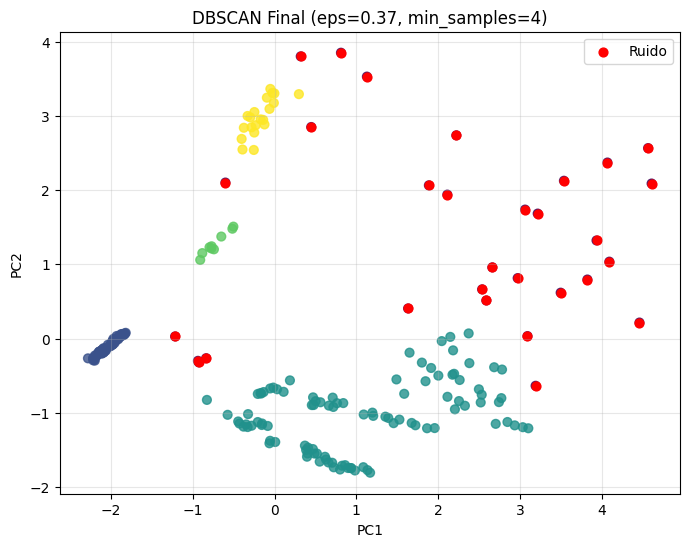

In [66]:
# VISUALIZACIÓN FINAL DBSCAN

best_eps = best_params['eps']
best_ms = best_params['min_samples']

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_dbscan = dbscan_final.fit_predict(X_reduced)

plt.figure(figsize=(8,6))
plt.scatter(
    df_pca_estrellas['PC1'],
    df_pca_estrellas['PC2'],
    c=labels_dbscan,
    cmap='viridis',
    s=40,
    alpha=0.8
)

# Resaltar ruido en rojo
noise = labels_dbscan == -1
plt.scatter(
    df_pca_estrellas['PC1'][noise],
    df_pca_estrellas['PC2'][noise],
    c='red',
    s=40,
    label='Ruido'
)

plt.title(f"DBSCAN Final (eps={best_eps}, min_samples={best_ms})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Una vez ajustados los hiperparámetros de cada método, procedemos a **comparar los tres algoritmos de clustering:**

#### **APARTADO 3.4: COMPARACIÓN DE ALGORITMOS DE CLUSTERING**

Una vez seleccionados los hiperparámetros de cada método, procedemos a comparar los tres algoritmos de clustering usando la mejor configuración encontrada para cada uno: **K-Means** con su mejor $K$, **Hierarchical Clustering** con su mejor combinación de `linkage + K`, y **DBSCAN** con sus mejores valores de `eps` y `min_samples`.

Para ello, entrenaremos cada modelo utilizando los datos reducidos a 2 dimensiones mediante PCA y representaremos los resultados de sus agrupaciones en gráficos de dispersión. Además, mostraremos una tabla resumen con la métrica usada en cada caso. En K-Means y clustering jerárquico usamos *Silhouette Score*; en DBSCAN usamos **DBCV**, por lo que su valor no debe compararse directamente con Silhouette, sino interpretarse como métrica interna específica para modelos basados en densidad.


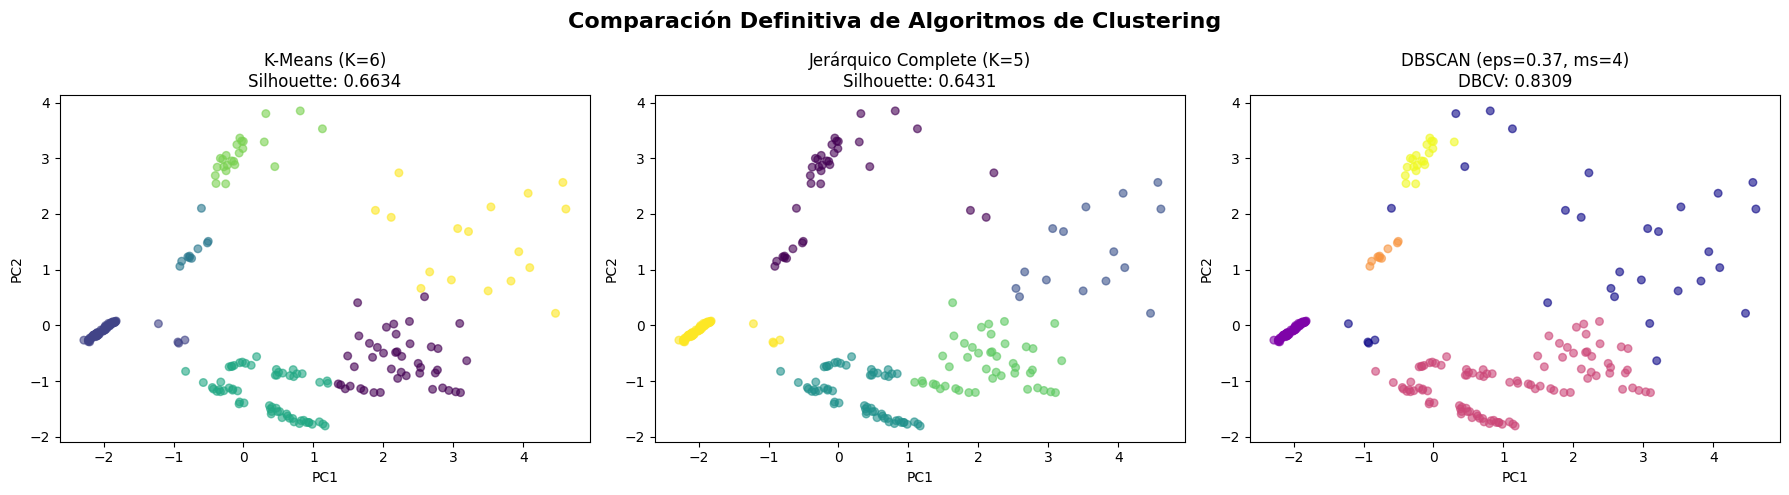

Resumen de la comparación final:


,Algoritmo,Hiperparámetros,Métrica usada,Score,Clusters generados,% ruido
0,K-Means,K=6,Silhouette,0.6634,6,0.0
1,Jerárquico,"linkage=complete, K=5",Silhouette,0.6431,5,0.0
2,DBSCAN,"eps=0.37, min_samples=4",DBCV,0.8309,4,12.5


In [67]:
# 1. Preparamos un lienzo para 3 gráficos en fila
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Modelo 1: K-MEANS con su mejor K
kmeans = KMeans(n_clusters=best_k_sil_kmeans, n_init=20, random_state=100522245)
labels_kmeans = kmeans.fit_predict(X_reduced)
sil_kmeans = silhouette_score(X_reduced, labels_kmeans)

axs[0].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6, s=30)
axs[0].set_title(f"K-Means (K={best_k_sil_kmeans})\nSilhouette: {sil_kmeans:.4f}")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")

# Modelo 2: HIERARCHICAL CLUSTERING con su mejor linkage y K
hc = AgglomerativeClustering(n_clusters=k_hier_final, linkage=best_linkage)
labels_hc = hc.fit_predict(X_reduced)
sil_hc = silhouette_score(X_reduced, labels_hc)

axs[1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_hc, cmap='viridis', alpha=0.6, s=30)
axs[1].set_title(f"Jerárquico {best_linkage.capitalize()} (K={k_hier_final})\nSilhouette: {sil_hc:.4f}")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")

# Modelo 3: DBSCAN con sus mejores hiperparámetros
best_eps = best_params['eps']
best_min_samples = best_params['min_samples']
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_dbscan = dbscan.fit_predict(X_reduced)
dbcv_score = dbcv.dbcv(X_reduced, labels_dbscan)

axs[2].scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_dbscan, cmap='plasma', alpha=0.6, s=30)
axs[2].set_title(f"DBSCAN (eps={best_eps}, ms={best_min_samples})\nDBCV: {dbcv_score:.4f}")
axs[2].set_xlabel("PC1")
axs[2].set_ylabel("PC2")

plt.suptitle("Comparación Definitiva de Algoritmos de Clustering", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

n_clusters_dbscan = len(set(labels_dbscan) - {-1})
noise_pct_dbscan = (np.sum(labels_dbscan == -1) / len(labels_dbscan)) * 100

comparativa_modelos = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Jerárquico', 'DBSCAN'],
    'Hiperparámetros': [
        f"K={best_k_sil_kmeans}",
        f"linkage={best_linkage}, K={k_hier_final}",
        f"eps={best_eps}, min_samples={best_min_samples}"
    ],
    'Métrica usada': ['Silhouette', 'Silhouette', 'DBCV'],
    'Score': [sil_kmeans, sil_hc, dbcv_score],
    'Clusters generados': [len(set(labels_kmeans)), len(set(labels_hc)), n_clusters_dbscan],
    '% ruido': [0.0, 0.0, noise_pct_dbscan]
})

print("Resumen de la comparación final:")
display(comparativa_modelos.round({'Score': 4, '% ruido': 2}))


### **Análisis de Resultados y Comparación de Modelos**

Tras ajustar los hiperparámetros de cada técnica, comparamos los **mejores modelos obtenidos para cada algoritmo**. Es decir, no se evalúa cuál es el mejor método bajo un mismo número de clústeres, sino cuál ofrece el mejor resultado después de optimizar sus hiperparámetros.

#### **1. Evaluación Cuantitativa (Métricas)**
* **K-Means (K=6):** es su mejor configuración según *Silhouette Score*, con un valor aproximado de **0.6634**.
* **Clustering Jerárquico (complete, K=5):** es la mejor configuración jerárquica encontrada según *Silhouette Score*, con un valor aproximado de **0.6431**.
* **DBSCAN (eps=0.37, min_samples=4):** es la mejor configuración según **DBCV**, con un valor aproximado de **0.8309** y alrededor de **12.5%** de ruido.

#### **2. Evaluación Cualitativa (Discusión)**
* **K-Means vs. Jerárquico:** como ambos se evalúan con *Silhouette*, la comparación directa favorece ligeramente a K-Means. Aun así, el clustering jerárquico obtiene un resultado cercano y confirma que hay una estructura de grupos bastante marcada en el espacio PCA. No obstante, creemos que al tener un cluster menos, está agrupando dos grupos de estrellas que no deberían estar en el mismo conjunto, por ello creemos que es mejor K-means.
* **DBSCAN:** aunque obtiene un DBCV alto, esta métrica no se compara directamente con Silhouette. Además, DBSCAN deja algunas estrellas como ruido, lo cual puede ser útil para detectar observaciones atípicas, pero es menos adecuado si el objetivo principal es asignar una clase a todas las estrellas (pues el ruido provoca que el número de clusters sea igual a 4, obteniendo así una clasificación no tan buena).

#### **3. Conclusión del Ganador**
El pipeline recomendado es **K-Means con K=6**, porque es el mejor modelo entre los métodos comparables por *Silhouette*, asigna todas las observaciones a un grupo y mantiene una interpretación natural respecto a las clases astronómicas del enunciado.


## **APARTADO 4: PIPELINE RECOMENDADO**

A partir de la comparación de los modelos optimizados, el algoritmo recomendado para este problema es **K-Means con K=6**.

La decisión se basa en comparar las mejores configuraciones de cada técnica: K-Means alcanza el mayor *Silhouette Score* frente al mejor modelo jerárquico, mientras que DBSCAN, aunque presenta buen DBCV, genera puntos de ruido y no clasifica todas las estrellas.

Por tanto, el **pipeline definitivo** que recomendamos para realizar el clustering se compone de tres etapas:
1. **Preprocesamiento:** estandarización de los datos numéricos (`StandardScaler`).
2. **Reducción de dimensionalidad:** extracción de las 2 componentes principales (`PCA(n_components=2)`).
3. **Clustering:** algoritmo K-Means con el número de clústeres seleccionado por Silhouette (`KMeans(n_clusters=6, n_init=20)`).


In [68]:
# Definimos el pipeline definitivo
pipeline_recomendado = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=100522245)),
    ('kmeans', KMeans(n_clusters=best_k_sil_kmeans, n_init=20, random_state=100522245))
])

# Le pasamos los datos originales (X) y dejamos que el pipeline haga todo el trabajo
label_finales = pipeline_recomendado.fit_predict(X)

# Guardamos las etiquetas en nuestro DataFrame principal para usarlas en el siguiente apartado
df['Cluster_Final'] = label_finales

print(f"Pipeline ejecutado con éxito. Las estrellas ya tienen su clúster asignado en el DataFrame con K={best_k_sil_kmeans}.")


Pipeline ejecutado con éxito. Las estrellas ya tienen su clúster asignado en el DataFrame con K=6.


## **APARTADO 5: ANÁLISIS ASTRONÓMICO Y COMPARACIÓN CON CLASES REALES**

El objetivo de este último apartado es comprobar si los grupos matemáticos que ha creado el **pipeline recomendado** tienen sentido en el mundo real.

Para ello, vamos a cruzar los resultados del algoritmo ganador tras la comparación de modelos optimizados (**K-Means con K=6**) con las características originales de las estrellas. Extraeremos el "perfil medio" de cada clúster calculando la media de sus variables numéricas (Temperatura, Luminosidad, Radio, Magnitud Absoluta) y el valor más frecuente (moda) de sus variables categóricas (Color y Clase Espectral).

Finalmente, compararemos estos perfiles generados por la Inteligencia Artificial con la tabla de clasificación astronómica oficial proporcionada en el enunciado (Enanas Rojas, Supergigantes, etc.) para ver si el algoritmo ha logrado descubrir las familias estelares por sí mismo.


In [69]:
# Para las variables numéricas calculamos la media de cada cluster
columnas_numericas = ['Temperature', 'L', 'R', 'A_M']
perfil_numerico = df.groupby('Cluster_Final')[columnas_numericas].mean().round(2)

# Para las variables categóricas (Color y Clase Espectral), calculamos la moda (el valor más frecuente)
columnas_categoricas = ['Color', 'Spectral_Class']
perfil_categorico = df.groupby('Cluster_Final')[columnas_categoricas].agg(lambda x: x.mode()[0])

# Unimos ambas tablas para tener el perfil completo de cada grupo
analisis_estrellas = pd.concat([perfil_numerico, perfil_categorico], axis=1)

# Mostramos
print("PERFIL MEDIO DE LOS CLÚSTERES")
display(analisis_estrellas)


PERFIL MEDIO DE LOS CLÚSTERES


,Temperature,L,R,A_M,Color,Spectral_Class
Cluster_Final,,,,,,
0,21516.58,212307.40,53.51,-5.59,blue,O
1,3213.88,0.02,0.26,14.60,red,M
2,3466.80,206600.00,129.50,-6.80,red,M
3,12522.15,133.97,1.25,8.42,blue white,B
4,3782.38,245541.67,1391.88,-9.92,red,M
5,24846.71,507569.47,1165.71,-8.82,blue,O


In [70]:
# Comparación formal clúster -> clase teórica (criterio objetivo)
tabla_teorica = pd.DataFrame({
    'Clase_Teorica': [
        'Enana roja', 'Enana marrón', 'Enana blanca',
        'Secuencia principal', 'Super gigante', 'Hiper gigante'
    ],
    'Temperature': [3000, 3300, 14000, 16000, 15000, 11000],
    'L': [7e-4, 5.5e-3, 2.5e-3, 3.2e4, 3.0e5, 3.0e5],
    'R': [1.0e-1, 3.5e-1, 1.0e-2, 4.4, 5.0e1, 1.4e3],
    'A_M': [17.5, 12.5, 12.6, -0.4, -6.4, -9.6]
})

# Distancia euclídea estandarizada en variables numéricas
num_cols = ['Temperature', 'L', 'R', 'A_M']
std_ref = tabla_teorica[num_cols].std(ddof=0).replace(0, 1)

X_clusters = analisis_estrellas[num_cols].copy()
X_theory = tabla_teorica[num_cols].copy()

Xc = X_clusters.div(std_ref, axis=1).to_numpy()
Xt = X_theory.div(std_ref, axis=1).to_numpy()

dist_matrix = np.sqrt(((Xc[:, None, :] - Xt[None, :, :]) ** 2).sum(axis=2))
best_idx = dist_matrix.argmin(axis=1)
best_dist = dist_matrix.min(axis=1)

correspondencia_clases = pd.DataFrame({
    'Cluster': analisis_estrellas.index,
    'Clase_teorica_mas_cercana': tabla_teorica.loc[best_idx, 'Clase_Teorica'].values,
    'Distancia_estandarizada': np.round(best_dist, 3)
}).set_index('Cluster').sort_index()

print('CORRESPONDENCIA FORMAL CLÚSTER -> CLASE TEÓRICA')
display(correspondencia_clases)

CORRESPONDENCIA FORMAL CLÚSTER -> CLASE TEÓRICA


,Clase_teorica_mas_cercana,Distancia_estandarizada
Cluster,,
0,Super gigante,1.378
1,Enana marrón,0.204
2,Super gigante,2.269
3,Enana blanca,0.490
4,Hiper gigante,1.409
5,Hiper gigante,3.032


### **Discusión y Comparación Astronómica**

Además del análisis cualitativo, hemos realizado una **comparación formal clúster -> clase teórica** usando un criterio objetivo: la distancia euclídea estandarizada entre cada clúster y los perfiles de referencia del enunciado (con `Temperature`, `L`, `R` y `A_M`).

La correspondencia obtenida es la siguiente:

- **Clúster 0 -> Super gigante** (distancia = 1.378)
- **Clúster 1 -> Enana marrón** (distancia = 0.204)
- **Clúster 2 -> Super gigante** (distancia = 2.269)
- **Clúster 3 -> Enana blanca** (distancia = 0.490)
- **Clúster 4 -> Hiper gigante** (distancia = 1.409)
- **Clúster 5 -> Hiper gigante** (distancia = 3.032)

Estos resultados muestran que el modelo captura correctamente la **estructura global** de la clasificación estelar: por un lado, estrellas frías y poco luminosas (enanas), y por otro, estrellas muy luminosas y de gran radio (gigantes/supergigantes/hipergigantes).

Además, las distancias más bajas (clústeres 1 y 3) indican una correspondencia muy clara con clases teóricas concretas, mientras que las distancias más altas (especialmente el clúster 5) reflejan que algunos grupos son más mixtos o intermedios. Esto es razonable, ya que K-Means optimiza similitud matemática en el espacio transformado (tras escalado y PCA), y la tabla del enunciado es una referencia simplificada.

### **Conclusión del apartado**

En conjunto, la evidencia (perfil medio + correspondencia formal por distancia) confirma que el pipeline **StandardScaler + PCA + K-Means (K=6)** es adecuado para esta práctica. Esta recomendación viene de comparar las mejores configuraciones de los algoritmos, no de imponer seis clústeres a todos los métodos.
